In [237]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import plotly.express as px 

In [238]:
original_df= pd.read_csv(r'C:\mariam\sumerge\song recommender\Songs_Recommender_System.csv')
df=original_df.copy()

In [239]:
df=df.tail(1000)

In [240]:
original_df.head()

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878000,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913000,3,0.101,-14.850,1,Gati Bali,5,1921,0.0339,110.339
3,0.1650,1921,0.967,['Frank Parker'],0.275,210000,0.309,0,3ftBPsC5vPBKxYSee08FDH,0.000028,5,0.381,-9.316,1,Danny Boy,3,1921,0.0354,100.109
4,0.2530,1921,0.957,['Phil Regan'],0.418,166693,0.193,0,4d6HGyGT8e121BsdKmw9v6,0.000002,3,0.229,-10.096,1,When Irish Eyes Are Smiling,2,1921,0.0380,101.665


In [241]:
original_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  object 
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   id                170653 non-null  object 
 9   instrumentalness  170653 non-null  float64
 10  key               170653 non-null  int64  
 11  liveness          170653 non-null  float64
 12  loudness          170653 non-null  float64
 13  mode              170653 non-null  int64  
 14  name              170653 non-null  object 
 15  popularity        170653 non-null  int64  
 16  release_date      17

In [242]:
# Count the total number of null values in each column
null_counts = original_df.isnull().sum()

# Print the count of null values
print("Count of null values in each column:")
print(null_counts)

# If you want the total number of null values across the entire DataFrame
total_nulls = original_df.isnull().sum().sum()
print(f"Total number of null values in the dataset: {total_nulls}")


Count of null values in each column:
valence             0
year                0
acousticness        0
artists             0
danceability        0
duration_ms         0
energy              0
explicit            0
id                  0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
name                0
popularity          0
release_date        0
speechiness         0
tempo               0
dtype: int64
Total number of null values in the dataset: 0


In [243]:
# sound_features = ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'valence']
# fig = px.line(release_date, x='year', y=sound_features)
# fig.show()

In [244]:

df.drop(['id', 'release_date','name'], axis=1, inplace=True)
df.head()

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo
169653,0.8720,2016,0.32900,['Los Cadetes De Linares'],0.774,146840,0.782,0,0.000,8,0.1970,-4.862,1,56,0.0408,101.652
169654,0.2760,2016,0.11700,['G Herbo'],0.483,208422,0.602,1,0.000,7,0.2510,-6.380,1,50,0.2210,92.734
169655,0.0501,2016,0.97600,['Benny Bernstein'],0.243,154246,0.123,0,0.879,8,0.1760,-20.642,1,59,0.0421,111.435
169656,0.6370,2016,0.00132,['Sabaton'],0.483,213512,0.938,0,0.000,11,0.0689,-5.685,0,61,0.0551,171.051
169657,0.1900,2016,0.38200,['Yo Trane'],0.491,252372,0.375,1,0.000,6,0.1030,-10.031,0,55,0.2000,97.116


In [245]:
df.describe()

,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.452117,2018.000000,0.293703,0.627640,207608.528000,0.589814,0.351000,7.998491e-02,5.104000,0.178837,-7.976969,0.616000,60.477000,0.121494,119.662949
std,0.236850,1.414921,0.296521,0.179508,53859.599107,0.217158,0.477522,2.369998e-01,3.631856,0.143037,5.567099,0.486601,7.659774,0.118752,31.470038
min,0.000000,2016.000000,0.000007,0.000000,56808.000000,0.000020,0.000000,0.000000e+00,0.000000,0.026100,-54.837000,0.000000,0.000000,0.000000,0.000000
25%,0.267000,2017.000000,0.038375,0.524750,176034.500000,0.467750,0.000000,0.000000e+00,1.000000,0.098275,-8.823250,0.000000,57.000000,0.039700,95.009500
50%,0.433500,2018.000000,0.193500,0.646000,202975.000000,0.616000,0.000000,5.050000e-07,5.000000,0.121000,-6.520000,1.000000,60.000000,0.064950,119.989000
75%,0.625250,2019.000000,0.469000,0.762000,234016.250000,0.749250,1.000000,5.822500e-04,8.000000,0.205500,-4.948250,1.000000,65.000000,0.167000,140.025500
max,0.975000,2020.000000,0.995000,0.985000,461854.000000,1.000000,1.000000,9.990000e-01,11.000000,0.987000,-0.092000,1.000000,86.000000,0.871000,213.788000


In [246]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 169653 to 170652
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   valence           1000 non-null   float64
 1   year              1000 non-null   int64  
 2   acousticness      1000 non-null   float64
 3   artists           1000 non-null   object 
 4   danceability      1000 non-null   float64
 5   duration_ms       1000 non-null   int64  
 6   energy            1000 non-null   float64
 7   explicit          1000 non-null   int64  
 8   instrumentalness  1000 non-null   float64
 9   key               1000 non-null   int64  
 10  liveness          1000 non-null   float64
 11  loudness          1000 non-null   float64
 12  mode              1000 non-null   int64  
 13  popularity        1000 non-null   int64  
 14  speechiness       1000 non-null   float64
 15  tempo             1000 non-null   float64
dtypes: float64(9), int64(6), object(1)


In [247]:
df.head()

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo
169653,0.8720,2016,0.32900,['Los Cadetes De Linares'],0.774,146840,0.782,0,0.000,8,0.1970,-4.862,1,56,0.0408,101.652
169654,0.2760,2016,0.11700,['G Herbo'],0.483,208422,0.602,1,0.000,7,0.2510,-6.380,1,50,0.2210,92.734
169655,0.0501,2016,0.97600,['Benny Bernstein'],0.243,154246,0.123,0,0.879,8,0.1760,-20.642,1,59,0.0421,111.435
169656,0.6370,2016,0.00132,['Sabaton'],0.483,213512,0.938,0,0.000,11,0.0689,-5.685,0,61,0.0551,171.051
169657,0.1900,2016,0.38200,['Yo Trane'],0.491,252372,0.375,1,0.000,6,0.1030,-10.031,0,55,0.2000,97.116


## Encoding

In [248]:
#Frequency encoding 

artist_freq = df['artists'].value_counts() / len(df)
df['artists_encoded'] = df['artists'].map(artist_freq)



In [249]:
df = df.drop('artists',axis=1)

In [250]:
df.head()

,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo,artists_encoded
169653,0.8720,2016,0.32900,0.774,146840,0.782,0,0.000,8,0.1970,-4.862,1,56,0.0408,101.652,0.001
169654,0.2760,2016,0.11700,0.483,208422,0.602,1,0.000,7,0.2510,-6.380,1,50,0.2210,92.734,0.002
169655,0.0501,2016,0.97600,0.243,154246,0.123,0,0.879,8,0.1760,-20.642,1,59,0.0421,111.435,0.001
169656,0.6370,2016,0.00132,0.483,213512,0.938,0,0.000,11,0.0689,-5.685,0,61,0.0551,171.051,0.002
169657,0.1900,2016,0.38200,0.491,252372,0.375,1,0.000,6,0.1030,-10.031,0,55,0.2000,97.116,0.001


## Standardization

In [251]:
from sklearn.preprocessing import StandardScaler

In [252]:

# Select the features to standardize
features_to_standardize = [ 'key', 'popularity', 'tempo','loudness']

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform only the selected features
df[features_to_standardize] = scaler.fit_transform(df[features_to_standardize])

df.head()


,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo,artists_encoded
169653,0.8720,2016,0.32900,0.774,146840,0.782,0,0.000,0.797788,0.1970,0.559812,1,-0.584774,0.0408,-0.572607,0.001
169654,0.2760,2016,0.11700,0.483,208422,0.602,1,0.000,0.522308,0.2510,0.287002,1,-1.368479,0.2210,-0.856129,0.002
169655,0.0501,2016,0.97600,0.243,154246,0.123,0,0.879,0.797788,0.1760,-2.276117,1,-0.192922,0.0421,-0.261584,0.001
169656,0.6370,2016,0.00132,0.483,213512,0.938,0,0.000,1.624225,0.0689,0.411905,0,0.068313,0.0551,1.633737,0.002
169657,0.1900,2016,0.38200,0.491,252372,0.375,1,0.000,0.246829,0.1030,-0.369144,0,-0.715392,0.2000,-0.716816,0.001


In [253]:
df.describe()

,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo,artists_encoded
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1000.000000,1.000000e+03,1000.000000,1.000000e+03,1000.000000,1.000000e+03,1000.00000
mean,0.452117,2018.000000,0.293703,0.627640,207608.528000,0.589814,0.351000,7.998491e-02,-1.421085e-17,0.178837,-8.526513e-17,0.616000,3.694822e-16,0.121494,7.815970e-17,0.00150
std,0.236850,1.414921,0.296521,0.179508,53859.599107,0.217158,0.477522,2.369998e-01,1.000500e+00,0.143037,1.000500e+00,0.486601,1.000500e+00,0.118752,1.000500e+00,0.00122
min,0.000000,2016.000000,0.000007,0.000000,56808.000000,0.000020,0.000000,0.000000e+00,-1.406045e+00,0.026100,-8.421528e+00,0.000000,-7.899353e+00,0.000000,-3.804343e+00,0.00100
25%,0.267000,2017.000000,0.038375,0.524750,176034.500000,0.467750,0.000000,0.000000e+00,-1.130566e+00,0.098275,-1.520908e-01,0.000000,-4.541570e-01,0.039700,-7.837863e-01,0.00100
50%,0.433500,2018.000000,0.193500,0.646000,202975.000000,0.616000,0.000000,5.050000e-07,-2.864983e-02,0.121000,2.618416e-01,1.000000,-6.230453e-02,0.064950,1.036586e-02,0.00100
75%,0.625250,2019.000000,0.469000,0.762000,234016.250000,0.749250,1.000000,5.822500e-04,7.977875e-01,0.205500,5.443112e-01,1.000000,5.907828e-01,0.167000,6.473694e-01,0.00100
max,0.975000,2020.000000,0.995000,0.985000,461854.000000,1.000000,1.000000,9.990000e-01,1.624225e+00,0.987000,1.417060e+00,1.000000,3.333750e+00,0.871000,2.992438e+00,0.00800


## Visualizig data



In [254]:

# sns.set_theme(style="ticks")

# features=df.drop(columns=['year','duration_ms','artists_encoded'],axis=1)  

# plt.figure(figsize=(12, 8))
# for feature in features:
#     sns.lineplot(data=df, x='year', y=feature, label=feature)

# plt.title('Features over Year')
# plt.xlabel('Year')
# plt.ylabel('Value')
# plt.legend(title='Feature')
# plt.show()


In [255]:
# Stand. the year

features_to_standardize = ['year']
scaler = StandardScaler()
df[features_to_standardize] = scaler.fit_transform(df[features_to_standardize])

df.head()


,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo,artists_encoded
169653,0.8720,-1.414214,0.32900,0.774,146840,0.782,0,0.000,0.797788,0.1970,0.559812,1,-0.584774,0.0408,-0.572607,0.001
169654,0.2760,-1.414214,0.11700,0.483,208422,0.602,1,0.000,0.522308,0.2510,0.287002,1,-1.368479,0.2210,-0.856129,0.002
169655,0.0501,-1.414214,0.97600,0.243,154246,0.123,0,0.879,0.797788,0.1760,-2.276117,1,-0.192922,0.0421,-0.261584,0.001
169656,0.6370,-1.414214,0.00132,0.483,213512,0.938,0,0.000,1.624225,0.0689,0.411905,0,0.068313,0.0551,1.633737,0.002
169657,0.1900,-1.414214,0.38200,0.491,252372,0.375,1,0.000,0.246829,0.1030,-0.369144,0,-0.715392,0.2000,-0.716816,0.001


## Feature Selection 

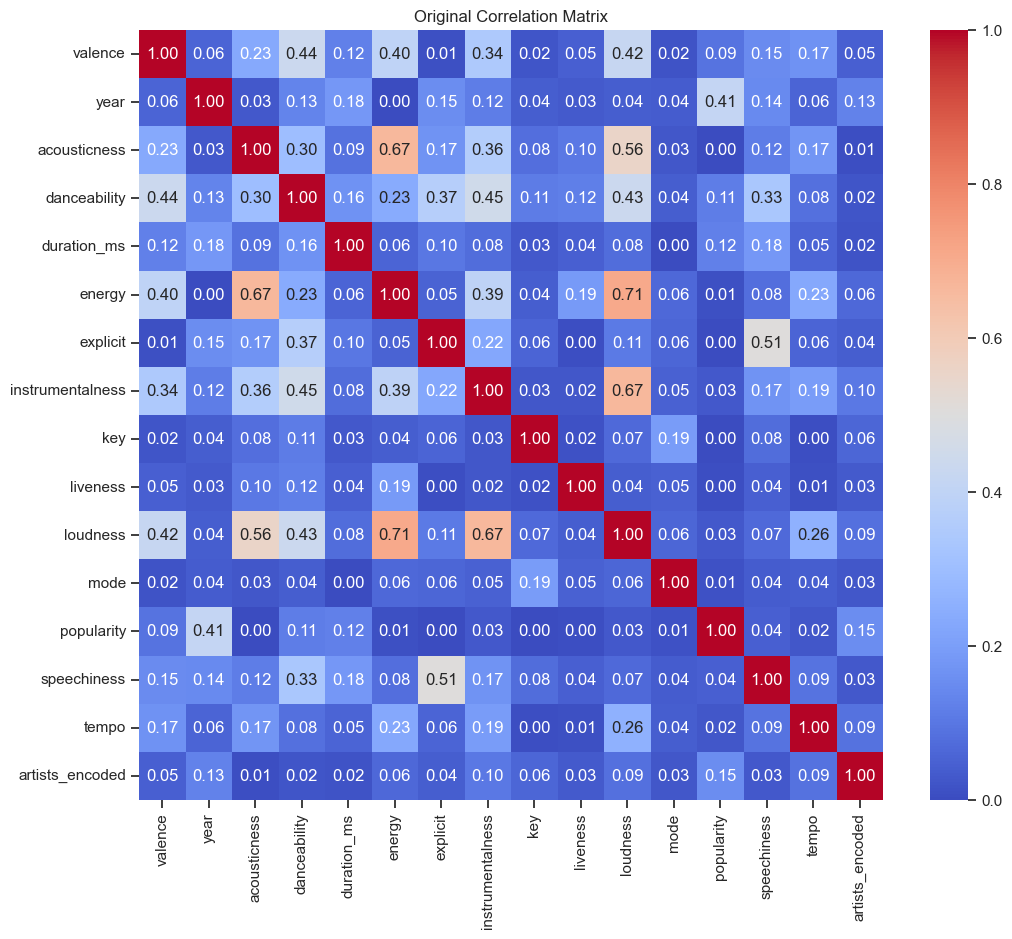

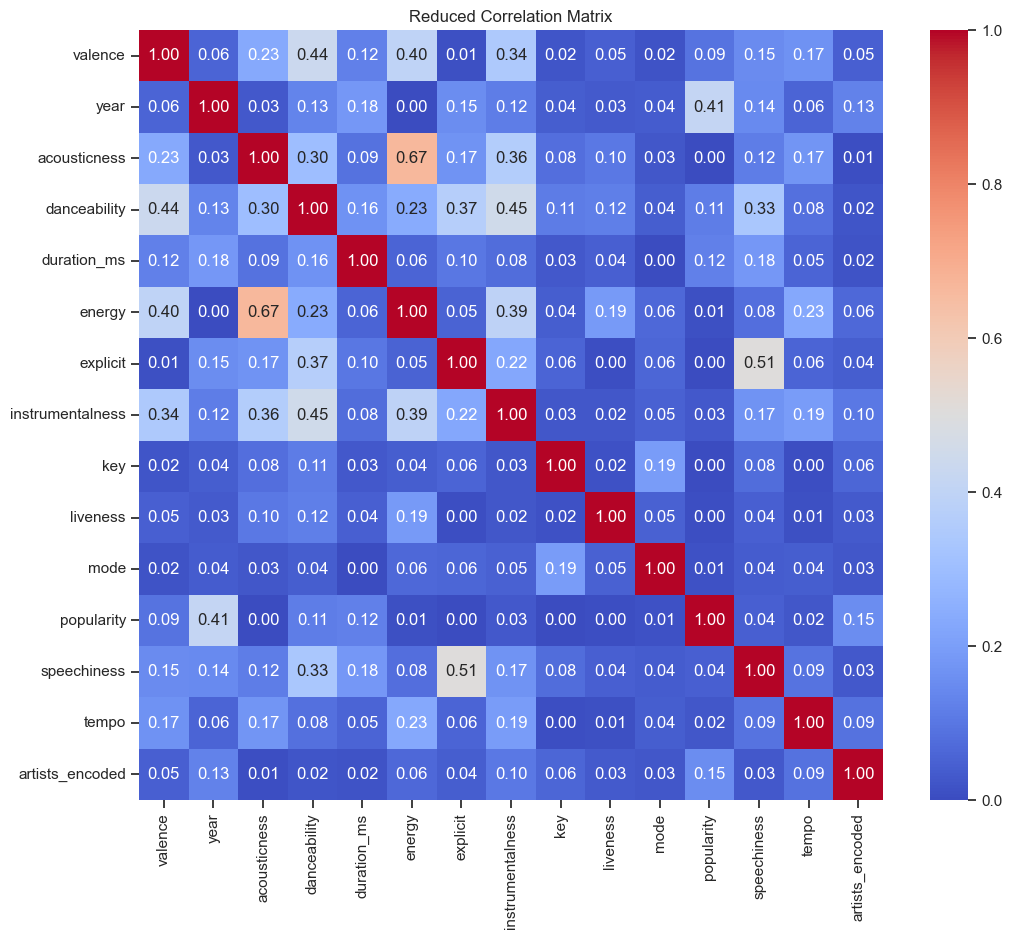

['loudness']

In [256]:

correlation_matrix = df.corr().abs()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=0, vmax=1)
plt.title('Original Correlation Matrix')
plt.show()

upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.7)]

df = df.drop(columns=to_drop)

reduced_correlation_matrix = df.corr().abs()
plt.figure(figsize=(12, 10))
sns.heatmap(reduced_correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=0, vmax=1)
plt.title('Reduced Correlation Matrix')
plt.show()

to_drop



In [257]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler


# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.select_dtypes(include=[np.number]))

# Apply Variance Threshold
var_thresh = VarianceThreshold(threshold=0.1)
X_var_thresh = var_thresh.fit_transform(X_scaled)

# Get the selected feature indices
selected_indices_var_thresh = var_thresh.get_support(indices=True)
selected_features_var_thresh = df.columns[selected_indices_var_thresh]

print(f"Selected features: {list(selected_features_var_thresh)}")

Selected features: ['valence', 'year', 'acousticness', 'danceability', 'duration_ms', 'energy', 'explicit', 'instrumentalness', 'key', 'liveness', 'mode', 'popularity', 'speechiness', 'tempo', 'artists_encoded']


In [258]:
# from sklearn.decomposition import PCA
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# df_scaled = scaler.fit_transform(df)


# pca = PCA(n_components=2) 
# df_pca = pca.fit_transform(df_scaled)

# explained_variance = pca.explained_variance_ratio_
# print("Explained Variance Ratio of each Principal Component:", explained_variance)
# print("Total Explained Variance:", np.sum(explained_variance))


# df_pca_df = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])

# # Output the PCA-transformed features
# print(df_pca_df.head())

# # If you want to add these components to the original dataframe
# df_new = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])
# df_new.head()


In [259]:
# # Elbow method
# import pandas as pd
# from sklearn.cluster import KMeans

# scaler = StandardScaler()
# scaled_features = scaler.fit_transform(df)

# # Define a range of cluster numbers to test
# cluster_range = range(1, 15)  # Test from 1 to 10 clusters
# inertia = []

# # Calculate inertia for each number of clusters
# for k in cluster_range:
#     kmeans = KMeans(n_clusters=k, random_state=0)
#     kmeans.fit(scaled_features)
#     inertia.append(kmeans.inertia_)

# # Plot the Elbow Method
# plt.figure(figsize=(10, 6))
# plt.plot(cluster_range, inertia, marker='o')
# plt.title('Elbow Method for Optimal Number of Clusters')
# plt.xlabel('Number of Clusters')
# plt.ylabel('Inertia')
# plt.xticks(cluster_range)
# plt.grid(True)
# plt.show()


In [260]:
# #Clustering using K-means and then visualize using t-SNE

# from sklearn.cluster import KMeans
# from sklearn.manifold import TSNE

# # Standardize the features
# scaler = StandardScaler()
# scaled_features = scaler.fit_transform(df)

# # Define the number of clusters for K-Means
# n_clusters = 10
# kmeans = KMeans(n_clusters=n_clusters, random_state=0)
# clusters = kmeans.fit_predict(scaled_features)

# # Add cluster labels to the original dataframe
# df['genres'] = clusters

# # Apply t-SNE for visualization
# tsne = TSNE(n_components=2, random_state=42)
# tsne_results = tsne.fit_transform(scaled_features)

# # Create a DataFrame with t-SNE results and cluster labels
# tsne_df = pd.DataFrame(data=tsne_results, columns=['TSNE1', 'TSNE2'])
# tsne_df['genres'] = df['genres']

# # Plot the t-SNE results
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x='TSNE1', y='TSNE2', hue='genres', data=tsne_df, palette='viridis')
# plt.title('t-SNE Visualization of K-Means Clusters')
# plt.xlabel('t-SNE Component 1')
# plt.ylabel('t-SNE Component 2')
# plt.legend(title='Genres')
# plt.show()

# from sklearn.metrics import silhouette_score
# score = silhouette_score(scaled_features, clusters)
# print(f'Silhouette Score fot t-SNE: {score:.4f}')
# #it took 1 hour to run


In [261]:
# #Clustering using K-means and then visualize using PCA
# from sklearn.metrics import silhouette_score
# from sklearn.decomposition import PCA


# # Standardize the features
# scaler = StandardScaler()
# scaled_features = scaler.fit_transform(df)

# # Define the number of clusters for K-Means
# n_clusters = 10
# kmeans = KMeans(n_clusters=n_clusters, random_state=42)
# clusters = kmeans.fit_predict(scaled_features)

# # Add cluster labels to the original dataframe
# df['cluster'] = clusters

# # Apply PCA for visualization
# pca = PCA(n_components=2)
# pca_results = pca.fit_transform(scaled_features)

# # Create a DataFrame with PCA results and cluster labels
# pca_df = pd.DataFrame(data=pca_results, columns=['PCA1', 'PCA2'])
# pca_df['cluster'] = df['cluster']

# # Plot the PCA results
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x='PCA1', y='PCA2', hue='cluster', data=pca_df, palette='viridis')
# plt.title('PCA Visualization of K-Means Clusters')
# plt.xlabel('Principal Component 1')
# plt.ylabel('Principal Component 2')
# plt.legend(title='Genres')
# plt.show()



# # score = silhouette_score(scaled_features, clusters)
# # print(f'Silhouette Score for PCA: {score:.4f}')
# #it took 6 seconds


In [262]:

# df['genres'] = df['cluster'].apply(lambda x: f'Genre {x + 1}')


# df.head()



## Recommender System


In [263]:
# from sklearn.metrics.pairwise import cosine_similarity

# model_df = df.drop(columns=['cluster', 'genres'])  
# scaler = StandardScaler()
# scaled_features = scaler.fit_transform(model_df)

# model_df.head()

In [264]:
# out_df = original_df[['artists', 'name', 'year']].copy()
# out_df['genres'] = df['genres']
# out_df




In [265]:
df

,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,mode,popularity,speechiness,tempo,artists_encoded
169653,0.8720,-1.414214,0.32900,0.774,146840,0.782,0,0.000000,0.797788,0.1970,1,-0.584774,0.0408,-0.572607,0.001
169654,0.2760,-1.414214,0.11700,0.483,208422,0.602,1,0.000000,0.522308,0.2510,1,-1.368479,0.2210,-0.856129,0.002
169655,0.0501,-1.414214,0.97600,0.243,154246,0.123,0,0.879000,0.797788,0.1760,1,-0.192922,0.0421,-0.261584,0.001
169656,0.6370,-1.414214,0.00132,0.483,213512,0.938,0,0.000000,1.624225,0.0689,0,0.068313,0.0551,1.633737,0.002
169657,0.1900,-1.414214,0.38200,0.491,252372,0.375,1,0.000000,0.246829,0.1030,0,-0.715392,0.2000,-0.716816,0.001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170648,0.6080,1.414214,0.08460,0.786,301714,0.808,0,0.000289,0.522308,0.0822,1,1.505105,0.0881,-0.465245,0.001
170649,0.7340,1.414214,0.20600,0.717,150654,0.753,0,0.000000,0.522308,0.1010,1,0.982635,0.0605,0.580940,0.001
170650,0.6370,1.414214,0.10100,0.634,211280,0.858,0,0.000009,-0.304129,0.2580,0,2.027575,0.0809,-0.889384,0.002
170651,0.1950,1.414214,0.00998,0.671,337147,0.623,1,0.000008,-0.855087,0.6430,1,1.243870,0.3080,-1.418183,0.002


In [266]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

def recommend_songs(song_name, df, original_df, num_recommendations=10):
    # Check if 'name' column is present in original_df
    if 'name' not in original_df.columns:
        raise ValueError("The 'name' column is not present in the original DataFrame.")
    
    # Ensure 'name' column is present in df before using it
    if 'name' in df.columns:
        df = df.drop(columns=['name'])
    
    # Calculate cosine similarity matrix
    cosine_sim = cosine_similarity(df)
    
    # Get the index of the song in the original DataFrame
    if song_name not in original_df['name'].values:
        raise ValueError(f"The song '{song_name}' is not found in the original DataFrame.")
    
    original_index = original_df[original_df['name'] == song_name].index[0]
    
    # Find the corresponding index in the numerical df
    if original_index not in df.index:
        raise ValueError(f"The index for the song '{song_name}' is not found in the numerical DataFrame.")
    
    df_index = df.index.get_loc(original_index)

    # Get the similarity scores for the input song
    sim_scores = list(enumerate(cosine_sim[df_index]))

    # Sort the songs based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the indices of the most similar songs (excluding the input song itself)
    similar_songs_indices = [i for i, _ in sim_scores[1:num_recommendations+1]]

    # Map these indices back to the original DataFrame to get the song names and other details
    recommended_songs = original_df.iloc[similar_songs_indices][['name', 'artists']]

    return recommended_songs

# Example usage
try:
    recommended_songs = recommend_songs('AYA', df, original_df, num_recommendations=10)
    print(recommended_songs)
except ValueError as e:
    print(e)


                                         name  \
963                                 The Chant   
746                                  Raymonde   
960                   Dead Man Blues - Take 1   
703                           Freeze And Melt   
744  Engualichaste Mi Corazón - Remasterizado   
905                                Melancholy   
925                             Keyhole Blues   
787                        You're Lucky To Me   
837                    Big Butter And Egg Man   
977   Kapitel 436 - Der Page und die Herzogin   

                                         artists  
963  ['Jelly Roll Morton & His Red Hot Peppers']  
746                                   ['Dranem']  
960  ['Jelly Roll Morton & His Red Hot Peppers']  
703             ['Joe Turner & His Memphis Men']  
744                          ['Ignacio Corsini']  
905          ['Louis Armstrong & His Hot Seven']  
925          ['Louis Armstrong & His Hot Seven']  
787                             ['Ethel Waters']  
8